<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/32_Supervised_Learning_with_scikit-learn/01_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/32_Supervised_Learning_with_scikit-learn/dataset/telecom_churn_clean.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
churn_df = pd.read_csv(url)
display(churn_df.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/customer_satisfaction.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
customer_satisfaction = pd.read_csv(url)
display(customer_satisfaction.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/food_preservation.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
food_preservation = pd.read_csv(url)
display(food_preservation.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/toy_durability.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
toy_durability = pd.read_csv(url)
display(toy_durability.head())

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


,Unnamed: 0,ApplicationID,ResponseTime,InterestRate,CustomerInteraction,SatisfactionQuality
0,0,1,Fast,Low,Poor,0.204979
1,1,2,Moderate,High,Good,0.462610
2,2,3,Slow,Medium,Average,0.874398
3,3,4,Moderate,High,Average,0.428884
4,4,5,Fast,High,Poor,0.126637


,ProductID,PreservationMethod,FoodType,NutrientRetention,ShelfLife
0,1,Drying,Fruit,59.17,184.04
1,2,Freezing,Meat,72.29,104.46
2,3,Drying,Fruit,80.06,75.03
3,4,Canning,Fruit,98.50,103.34
4,5,Canning,Vegetable,59.09,97.46


,Toy_Type,Durability_Score
0,Recreational,67.2
1,Recreational,80.9
2,Recreational,69.7
3,Recreational,82.7
4,Educational,79.6


### Supervised Learning

**Binary classification**  
There are two types of supervised learning—classification and regression. Binary classification is used to predict a target variable that has only two labels, typically represented numerically with a zero or a one.

The .head() of a dataset, churn_df, is shown below. You can expect the rest of the data to contain similar values.

      account_length  total_day_charge  total_eve_charge  total_night_charge  total_intl_charge  customer_service_calls  churn
    0             101             45.85             17.65                9.64               1.22                       3      1
    1              73             22.30              9.05                9.98               2.75                       2      0
    2              86             24.62             17.53               11.49               3.13                       4      0
    3              59             34.73             21.02                9.66               3.24                       1      0
    4             129             27.42             18.75               10.11               2.59                       1      0
Looking at this data, which column could be the target variable for binary classification?

[
  - "customer_service_calls"


- "total_night_charge"


- --"churn"


- "account_length"
]


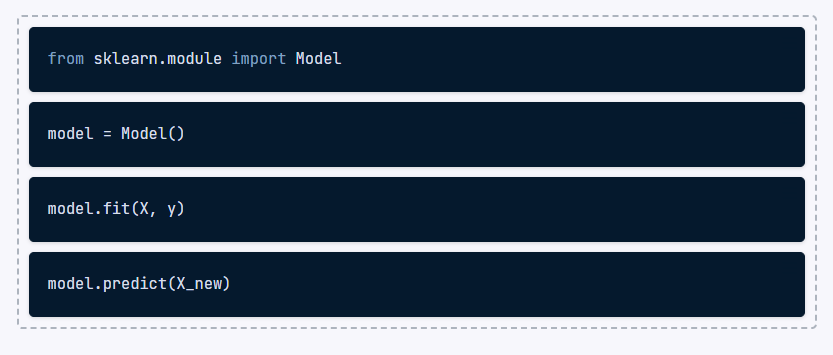

**k-Nearest Neighbors: Fit**  
In this exercise, you will build your first classification model using the churn_df dataset, which has been preloaded for the remainder of the chapter.

The target, "churn", needs to be a single column with the same number of observations as the feature data. The feature data has already been converted into numpy arrays.

"account_length" and "customer_service_calls" are treated as features because account length indicates customer loyalty, and frequent customer service calls may signal dissatisfaction, both of which can be good predictors of churn.

In [4]:
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

y = churn_df["churn"].values
X = churn_df[["account_length", "customer_service_calls"]].values

# Create a KNN classifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)

# Fit the classifier to the data
knn.fit(X, y)

# Predict the labels for the X_new
y_pred = knn.predict(np.array([[30.0, 17.5],
                  [107.0, 24.1],
                  [213.0, 10.9]]))

# Print the predictions
print("Predictions: {}".format(y_pred))

# The model has predicted the first and third customers will not churn in the new array. But how do we know how
# accurate these predictions are? Let's explore how to measure a model's performance in the next video.

Predictions: [0 1 0]


**Train/test split + computing accuracy**  
It's time to practice splitting your data into training and test sets with the churn_df dataset!

NumPy arrays have been created for you containing the features as X and the target variable as y.

In [5]:
# Import the module
from sklearn.model_selection import train_test_split

X = churn_df.drop("churn", axis=1).values
y = churn_df["churn"].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the classifier to the training data
knn.fit(X_train, y_train)

# Print the accuracy
print(knn.score(X_test, y_test))

# In a few lines of code you split a dataset, fit a KNN model, and found its accuracy to be 87%!

0.8545727136431784


**Overfitting and underfitting**  
Interpreting model complexity is a great way to evaluate supervised learning performance. Your aim is to produce a model that can interpret the relationship between features and the target variable, as well as generalize well when exposed to new observations.

The training and test sets have been created from the churn_df dataset and preloaded as X_train, X_test, y_train, and y_test.

In addition, KNeighborsClassifier has been imported for you along with numpy as np.

In [6]:
# Create neighbors
neighbors = np.arange(1, 13)
train_accuracies = {}
test_accuracies = {}

for neighbor in neighbors:

	# Set up a KNN Classifier
	knn = KNeighborsClassifier(n_neighbors=neighbor)

	# Fit the model
	knn.fit(X_train, y_train)

	# Compute accuracy
	train_accuracies[neighbor] = knn.score(X_train, y_train)
	test_accuracies[neighbor] = knn.score(X_test, y_test)
print(neighbors, '\n', train_accuracies, '\n', test_accuracies)

# Notice how training accuracy decreases as the number of neighbors initially gets larger, and vice versa for the testing accuracy?
# These scores would be much easier to interpret in a line plot, so let's produce a model complexity curve of these results.

[ 1  2  3  4  5  6  7  8  9 10 11 12] 
 {np.int64(1): 1.0, np.int64(2): 0.8885971492873218, np.int64(3): 0.8994748687171793, np.int64(4): 0.8750937734433608, np.int64(5): 0.878469617404351, np.int64(6): 0.8660915228807202, np.int64(7): 0.8705926481620405, np.int64(8): 0.8615903975993998, np.int64(9): 0.86384096024006, np.int64(10): 0.858589647411853, np.int64(11): 0.8604651162790697, np.int64(12): 0.8574643660915229} 
 {np.int64(1): 0.7856071964017991, np.int64(2): 0.8470764617691154, np.int64(3): 0.8320839580209896, np.int64(4): 0.856071964017991, np.int64(5): 0.8545727136431784, np.int64(6): 0.8590704647676162, np.int64(7): 0.8605697151424287, np.int64(8): 0.8620689655172413, np.int64(9): 0.863568215892054, np.int64(10): 0.8605697151424287, np.int64(11): 0.8605697151424287, np.int64(12): 0.8605697151424287}


**Visualizing model complexity**  
Now you have calculated the accuracy of the KNN model on the training and test sets using various values of n_neighbors, you can create a model complexity curve to visualize how performance changes as the model becomes less complex!

The variables neighbors, train_accuracies, and test_accuracies, which you generated in the previous exercise, have all been preloaded for you. You will plot the results to aid in finding the optimal number of neighbors for your model.

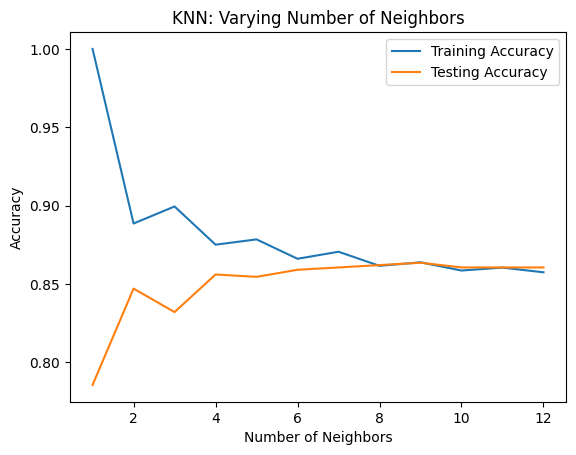

In [7]:
# Add a title
plt.title("KNN: Varying Number of Neighbors")

# Plot training accuracies
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")

# Plot test accuracies
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")

plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

# Display the plot
plt.show()

# See how training accuracy decreases and test accuracy increases as the number of neighbors gets larger. For the test set,
# accuracy peaks with 7 neighbors, suggesting it is the optimal value for our model. Now let's explore regression models!